In [98]:
import numpy as np


In [99]:
import typing
import math
import collections

T = typing.TypeVar("T", int, float)


class Point(typing.Generic[T]):
    def __init__(self, data: tuple[T, T]):
        self.x, self.y = data

    @property
    def position(self):
        return self.x, self.y

    def __iter__(self) -> typing.Iterator[T]:
        return iter((self.x, self.y))

    def __getitem__(self, item):
        data = [self.x, self.y]
        return data[item]

    def __setitem__(self, key, value):
        data = [self.x, self.y]
        data[key] = value

    def __str__(self):
        return str((self.x, self.y))


class Circle(Point[T]):
    def __init__(self, data: tuple[T, T], radius: T = 0) -> None:
        super().__init__(data)
        self.radius = radius


class BrushstrokeNode(Circle[T]):
    def __init__(self, img_source: np.ndarray, position: tuple[T, T], radius: T, sub_matrix_size=1):
        super().__init__(position, radius)

        self.__img_source = img_source
        self.fill_color = (0, 0, 0, 0)
        self.sub_matrix_size = sub_matrix_size

        self.update()

    def update(self):
        (x, y), r = self.position, self.radius
        sub_m = self.__img_source[y:y + self.sub_matrix_size, x: x + self.sub_matrix_size]
        media_color = np.median(sub_m, axis=0).astype(int)

        r, g, b = media_color[0]

        self.fill_color = (r, g, b, self.alpha)

    @property
    def alpha(self):
        return self.fill_color[3]

    @property
    def rgb(self) -> tuple[int, int, int]:
        return self.fill_color[0:3]

    @rgb.setter
    def rgb(self, rgb):
        r, g, b = rgb
        self.fill_color = (r, g, b, self.alpha)

    @property
    def rgba(self) -> tuple[int, int, int]:
        return self.fill_color[0:4]

    @property
    def hex(self):
        r, g, b = self.rgb

        r = max(0, min(r, 255))
        g = max(0, min(g, 255))
        b = max(0, min(b, 255))

        hex_color = '#{:02X}{:02X}{:02X}'.format(r, g, b)

        return hex_color

    @property
    def xyr(self):
        (x, y), r = self.position, self.radius
        return x - r, y - r, x + r, y + r

    def draw(self, canvas):
        canvas.ellipse(self.xyr, fill=self.rgb)

        return canvas


class Rect(typing.Generic[T]):
    def __init__(self, position: typing.Tuple[T, T], size: typing.Tuple[T, T]):
        self.position = position
        self.size = size

    @property
    def width(self):
        return self.size[0]

    @property
    def height(self):
        return self.size[1]

    @property
    def right(self):
        return self.position[0] + self.width

    @property
    def left(self):
        return self.position[0]

    @property
    def top(self):
        return self.position[1]

    @property
    def bottom(self):
        return self.position[1] + self.height

    def __str__(self):
        x, y = self.position

        return f"[{x}, {y}, {self.right}, {self.bottom}]"

    def __iter__(self):
        x, y = self.position

        return iter((x, y, self.right, self.bottom))


def collision_point(a: Rect[T], x: T, y: T):
    x_axis_left = x > a.left
    x_axis_right = x < a.right
    x_axis = x_axis_left and x_axis_right

    y_axis_top = y > a.top
    y_axis_bottom = y < a.bottom
    y_axis = y_axis_top and y_axis_bottom

    return x_axis and y_axis


def collision_circle(a: Circle, b: Circle):
    x1, y1 = a.position
    x2, y2 = b.position

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return distance <= a.radius + b.radius


def collision_rect(a: Rect[T], b: Rect[T]):
    return (a.bottom > b.top or b.top < a.bottom) and (a.right > b.left or a.left < b.right)


def is_collision(that: Rect[T], other: Rect[T] | Point) -> bool:
    collision_aabb: typing.Callable[[Rect[T], Rect[T]], bool] = lambda a, b: (
            (a.bottom > b.top or b.top < a.bottom) and
            (a.right > b.left or a.left < b.right)
    )

    if isinstance(other, Rect):
        return collision_rect(that, other)

    _x, _y, = other

    return collision_point(that, _x, _y)


def create_child(parent: Rect[T], size_limit: typing.Tuple[T, T]):
    w, h = parent.width / 2, parent.height / 2
    x, y = parent.position

    child = []

    if w >= size_limit[0] and h >= size_limit[1]:
        size = w, h

        rects = [
            Rect((x, y), size),
            Rect((x + w, y), size),
            Rect((x, y + h), size),
            Rect((x + w, y + h), size),
        ]

        for rect in rects:
            child.append(
                TreeNode(rect, size_limit)
            )

    return child


class TreeNode(typing.Generic[T]):
    def __init__(self, rect: Rect[T], size_limit=None):
        self.__rect = rect
        self.__points = collections.deque()

        size_limit_child = size_limit if size_limit else (
            rect.size[0] / 2, rect.size[1] / 2
        )

        self.__child = create_child(
            self.__rect,
            size_limit_child
        )

    @property
    def rect(self):
        return self.__rect

    @property
    def child(self):
        return self.__child

    @property
    def points(self):
        return self.__points

    def insert_point(self, point: Point):
        if not len(self.child) > 0:
            self.points.append(point)
        else:
            for c in self.child:
                if is_collision(c.rect, point):
                    return c.insert_point(point)

    def __str__(self):
        return str(self.rect)

    def __iter__(self):
        def iter_child(child: list[TreeNode], points=None):
            if points is None:
                points = []

            for c in child:
                if len(c.child) != 0:
                    iter_child(c.child, points)
                else:
                    if len(c.points) > 0:
                        points.append(list(c.points))

            return points

        return iter(iter_child(self.child))

    def get_points_with_root(self):
        def iter_child(child: list[TreeNode], points=None):
            if points is None:
                points = []

            for c in child:
                if len(c.child) != 0:
                    iter_child(c.child, points)
                else:
                    if len(c.points) > 0:
                        points.append((c, list(c.points)))

            return points

        return list(iter_child(self.child))

    def sort(self, root=False):
        if root:
            return self.get_points_with_root()

        return list(self)


In [100]:
import random

from PIL import Image, ImageDraw


def pointillism_effect(img: Image, n_points: int, min_alpha: int = 250, point_size_range: tuple[int, int] = (1, 5),
                       sub_matrix_size: int = 5) -> Image:
    m_img_source = np.array(img)
    img_canvas = Image.new("RGBA", size=img.size, color="white")
    canvas = ImageDraw.Draw(img_canvas)

    for _ in range(n_points):
        r = random.randint(*point_size_range)
        x, y = random.randint(0, img_canvas.width - 1), random.randint(0, img_canvas.height - 1)

        sub_m = m_img_source[y:y + sub_matrix_size, x: x + sub_matrix_size]
        media_color = np.median(sub_m, axis=0).astype(int)[0]

        alpha = random.randint(min_alpha, 255)
        fill_color = (*media_color, alpha)
        xyr = x - r, y - r, x + r, y + r

        canvas.ellipse(xyr)

    return img_canvas


def draw_nodes(img: Image, nodes: list[BrushstrokeNode]):
    img_canvas = Image.new("RGB", size=img.size, color="white")
    canvas = ImageDraw.Draw(img_canvas)

    for node in nodes:
        node.draw(canvas)

    return img_canvas


def draw_from_pixel(img: Image, nodes: list[BrushstrokeNode]):
    img_canvas = Image.new("RGB", size=img.size, color="white")

    for node in nodes:
        position = node.position
        rgb = node.rgb

        img_canvas.putpixel(position, rgb)

    return img_canvas


In [101]:
def get_median_color(points):
    autosum = np.array([p.rgb for p in points]).sum(axis=0)
    median_points = autosum / len(points)

    return median_points


def set_median_color(points):
    median_color = get_median_color(points).astype(np.int32)

    for point in points:
        point.rgb = median_color

    return points


# Runtime

In [102]:
FILENAME = "resources/tiger.jpg"
MAX_PARTICLES = 150000

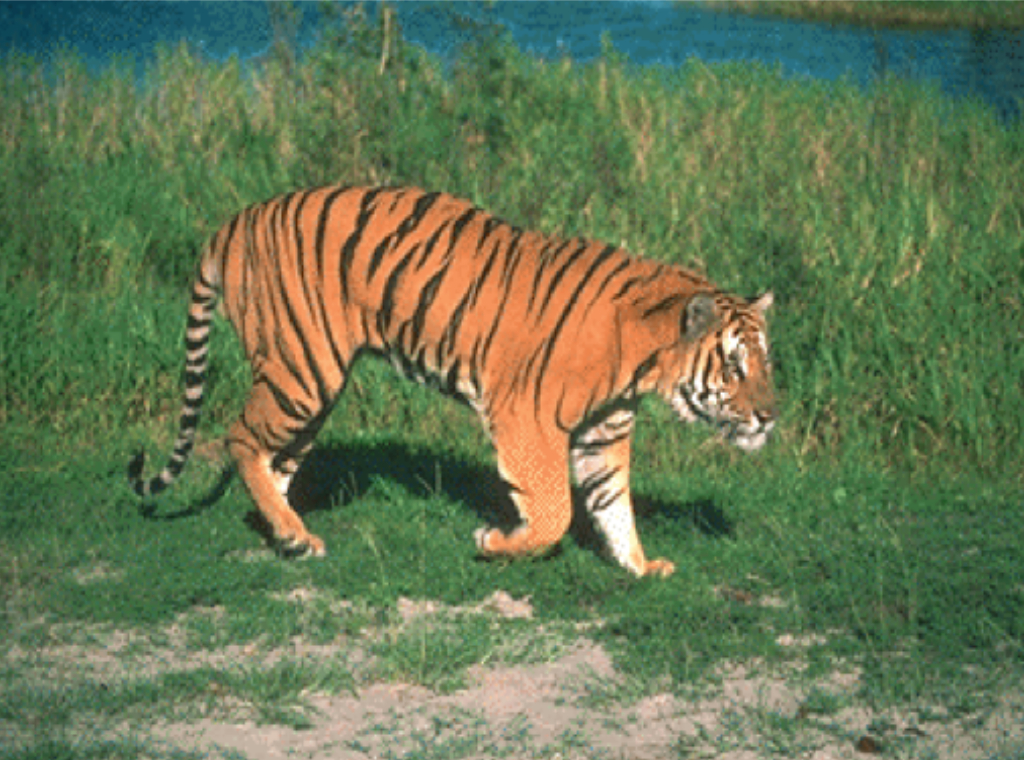

In [103]:
source_img_rgb = Image.open(FILENAME).convert("RGB")
img_array_rgb = np.asarray(source_img_rgb)

source_img_rgb

In [104]:
width, height = source_img_rgb.size
source_points = []
radius = 5

for _ in range(MAX_PARTICLES):
    x, y = random.randint(0, width - 1), random.randint(0, height - 1)
    r = 1

    point = BrushstrokeNode(img_array_rgb, (x, y), r)
    point.radius = radius

    source_points.append(point)

In [105]:
yellow_points = [*filter(lambda p: p.rgb[0] > 127.5 > p.rgb[2] < p.rgb[1], source_points)]
purple_points = [*filter(lambda p: p.rgb[0] > 127.5 > p.rgb[1] and p.rgb[2] > 127.5, source_points)]
blue_points = [*filter(lambda p: p.rgb[0] < 127.5 < p.rgb[2] and p.rgb[1] < 127.5, source_points)]
red_points = [*filter(lambda p: p.rgb[0] > 127.5 > p.rgb[1] and p.rgb[2] < 127.5, source_points)]
green_points = [*filter(lambda p: p.rgb[0] < 127.5 < p.rgb[1] and p.rgb[2] < 127.5, source_points)]
cyan_points = [*filter(lambda p: p.rgb[0] < 127.5 < p.rgb[1] and p.rgb[2] > 127.5, source_points)]
white_points = [*filter(lambda p: p.rgb[0] > 127.5 and p.rgb[1] > 127.5 and p.rgb[2] > 127.5, source_points)]
black_points = [*filter(lambda p: p.rgb[0] < 127.5 and p.rgb[1] < 127.5 and p.rgb[2] < 127.5, source_points)]

ALL_POINTS = [
    yellow_points, purple_points, blue_points, red_points, green_points, cyan_points, white_points, black_points
]

ALL_POINTS_LABEL = [*zip(ALL_POINTS, ('Yellow', 'Purple', 'Blue', 'Red', 'Green', 'Cyan', 'White', 'Black'))]

/tmp/ipykernel_4855/110008646.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


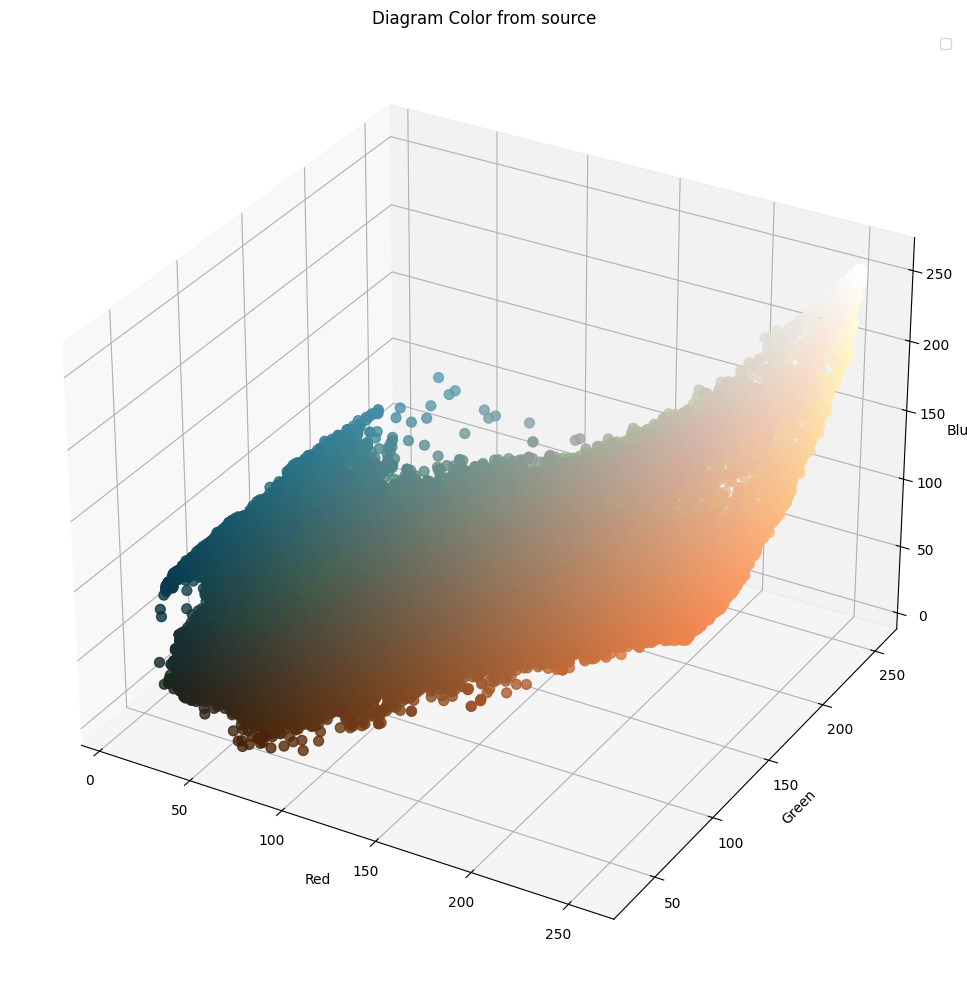

In [106]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(projection='3d')

rgb_points_source = [point.rgb for point in source_points]
x = [rgb[0] for rgb in rgb_points_source]
y = [rgb[1] for rgb in rgb_points_source]
z = [rgb[2] for rgb in rgb_points_source]

ax.scatter(
    x, y, z,
    color=np.array(rgb_points_source) / 255,
    marker='o',
    s=50,
    alpha=0.8,
)

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title('Diagram Color from source')
ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_4855/2354817801.py:3: RuntimeWarning: invalid value encountered in scalar divide
  median_points = autosum / len(points)


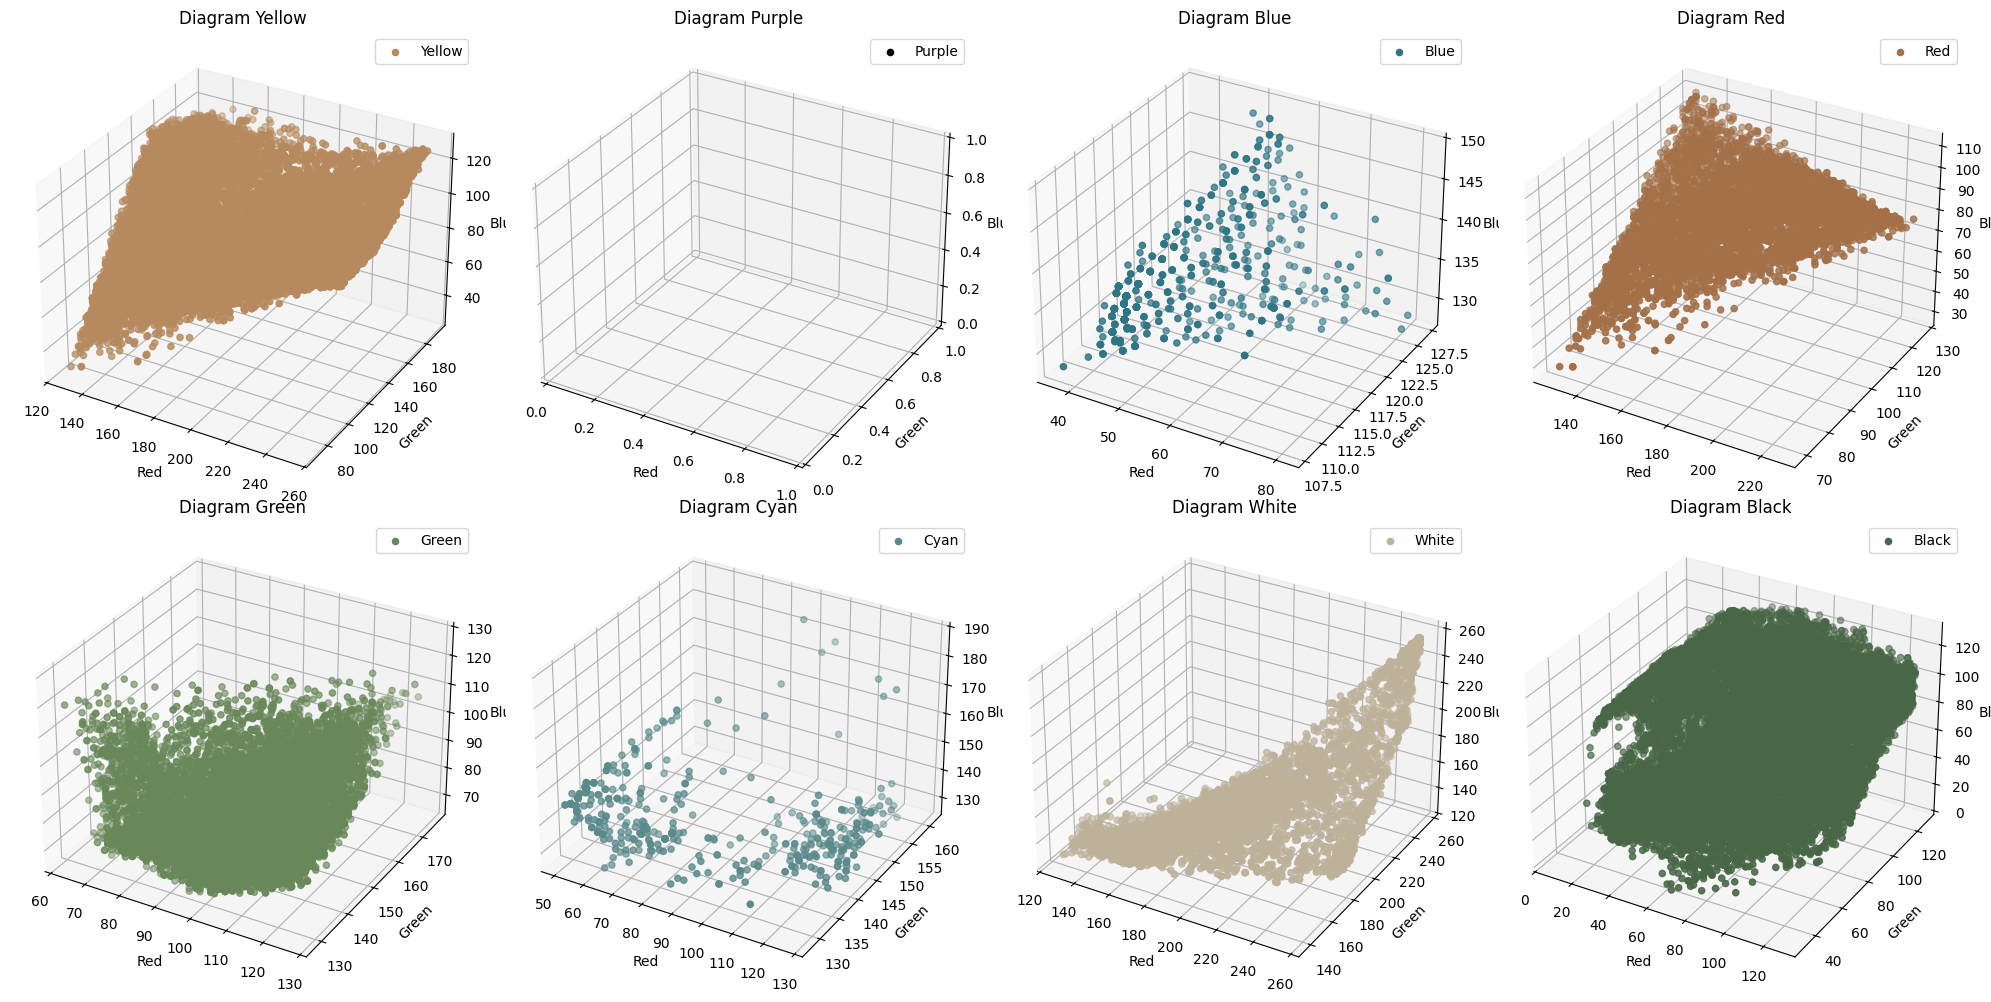

In [107]:
import numpy as np
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(20, 10))

for n, (points, color) in enumerate(ALL_POINTS_LABEL):
    ax = fig.add_subplot(2, 4, n + 1, projection='3d')

    x = [point.rgb[0] for point in points]
    y = [point.rgb[1] for point in points]
    z = [point.rgb[2] for point in points]

    median_color = get_median_color(points)
    median_color = median_color / 255

    if not isinstance(median_color, np.ndarray):
        median_color = 0, 0, 0

    ax.scatter(x, y, z, color=median_color, marker='o', label=f'{color}')

    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    ax.set_title(f'Diagram {color}')
    ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_4855/2354817801.py:3: RuntimeWarning: invalid value encountered in scalar divide
  median_points = autosum / len(points)


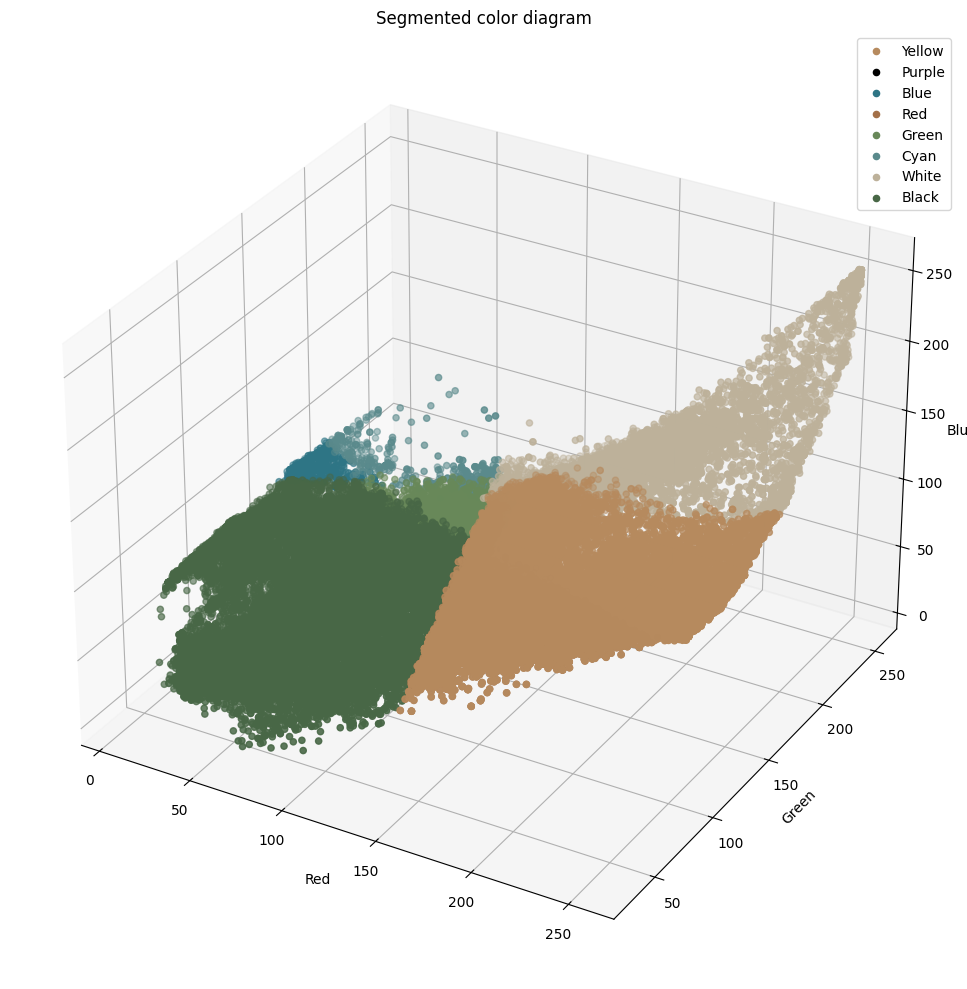

In [108]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(projection='3d')

for n, (points, color) in enumerate(ALL_POINTS_LABEL):
    x = [point.rgb[0] for point in points]
    y = [point.rgb[1] for point in points]
    z = [point.rgb[2] for point in points]

    median_color = get_median_color(points)
    median_color = median_color / 255

    if not isinstance(median_color, np.ndarray):
        median_color = 0, 0, 0

    ax.scatter(x, y, z, color=median_color, marker='o', label=f'{color}')

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
ax.set_title(f'Segmented color diagram')
ax.legend()

plt.tight_layout()
plt.show()

In [109]:
img_pointillism = draw_nodes(source_img_rgb, source_points)

points_segmentation = []

for points in ALL_POINTS:
    points_segmentation += set_median_color(points)

img_segmentation = draw_nodes(source_img_rgb, points_segmentation)

/tmp/ipykernel_4855/2354817801.py:3: RuntimeWarning: invalid value encountered in scalar divide
  median_points = autosum / len(points)
/tmp/ipykernel_4855/2354817801.py:9: RuntimeWarning: invalid value encountered in cast
  median_color = get_median_color(points).astype(np.int32)


/tmp/ipykernel_4855/2354817801.py:3: RuntimeWarning: invalid value encountered in scalar divide
  median_points = autosum / len(points)


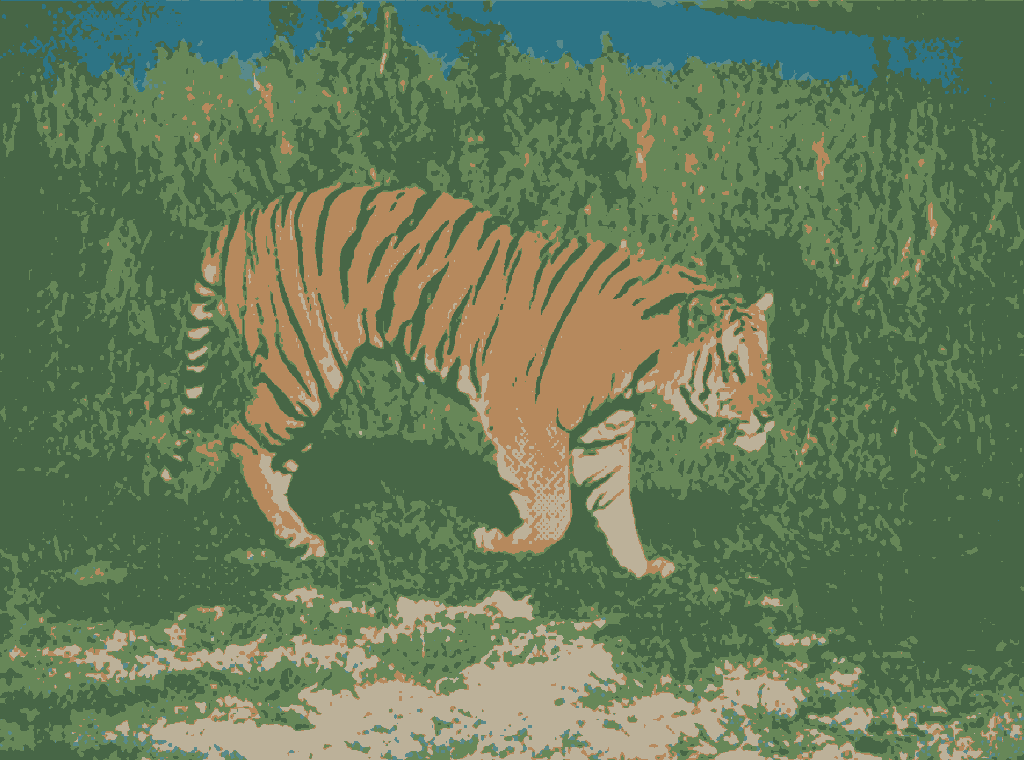

In [110]:
import math


def get_median_colors(all_points):
    colors = {}

    for n, (points, color) in enumerate(all_points):
        median_color = get_median_color(points)

        if not isinstance(median_color, np.ndarray):
            continue

        colors[color] = median_color

    return colors


def draw_from_buffer(source_img, colors):
    buffer = np.full(source_img.shape, 255, dtype=np.uint8)

    for y, row in enumerate(source_img):
        for x, original_source_color in enumerate(row):
            all_colors = []

            for name, color in colors.items():
                all_colors.append((math.dist(color, original_source_color), color, name))

            all_colors.sort(key=lambda item: item[0])

            buffer[y, x] = all_colors[0][1]

    return buffer


img_segmentation = draw_from_buffer(img_array_rgb, get_median_colors(ALL_POINTS_LABEL))
Image.fromarray(img_segmentation)

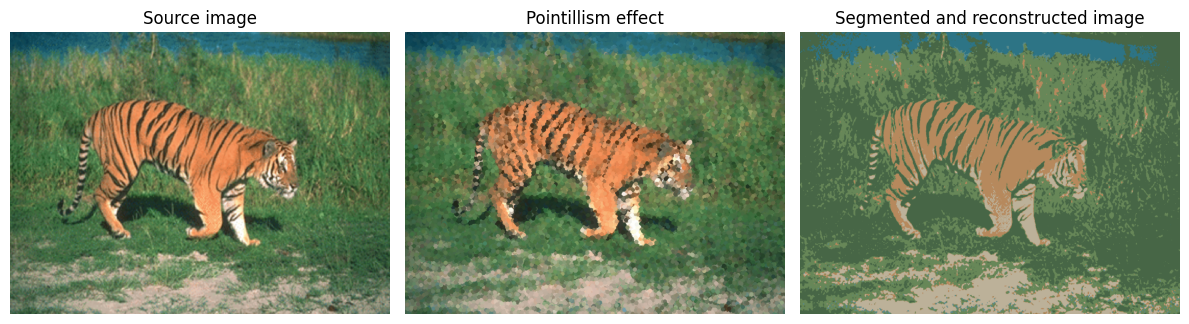

In [111]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(source_img_rgb)
axes[0].set_title("Source image")
axes[0].axis('off')

axes[1].imshow(img_pointillism)
axes[1].set_title("Pointillism effect")
axes[1].axis('off')

axes[2].imshow(img_segmentation)
axes[2].set_title("Segmented and reconstructed image")
axes[2].axis('off')

plt.tight_layout()
plt.show()